In [1]:
# ---------------------------------------------------------------------------
# Path setup — run this first. Anchors all paths to the repo root so the
# notebook works regardless of the directory it's launched from.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Walk upward until we find a dir containing both 'src' and 'data'."""
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    # Fallback: assume the notebook lives in <root>/notebooks/
    return start.parent


# Path.cwd() is where Jupyter was launched; __file__ isn't defined in nbs.
REPO_ROOT = _find_repo_root(Path.cwd())

DATA_DIR    = REPO_ROOT / "data" / "Scenario5"
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
CSV_DIR     = RESULTS_DIR / "csv"
for _d in (FIGURES_DIR, CSV_DIR):
    _d.mkdir(parents=True, exist_ok=True)

_diffputer = REPO_ROOT / "external" / "DiffPuter"
for _p in (
    REPO_ROOT,                             # so `import external...` resolves
    REPO_ROOT / "src",
    _diffputer / "baselines" / "GRAPE",
    _diffputer / "baselines",
    _diffputer,
):
    _sp = str(_p.resolve())
    if _p.exists() and _sp not in sys.path:
        sys.path.insert(0, _sp)

In [2]:
# Check environment and imports
from common.environment import check_environment
check_environment()

Required packages
------------------------------------------------------------
  ✓ numpy              OK       1.26.4
  ✓ pandas             OK       2.3.3
  ✓ scipy              OK       1.17.1
  ✓ scikit-learn       OK       1.6.1
  ✓ matplotlib         OK       3.10.9
  ✓ statsmodels        OK       0.14.6
  ✓ fancyimpute        OK       0.7.0
  ✓ hyperimpute        OK       0.1.17
  ✓ torch              OK       2.4.1
  ✓ torch_geometric    OK       2.7.0
  ✓ h5py               OK       3.14.0
  ✓ networkx           OK       3.6.1


I0000 00:00:1779544630.766759   13145 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


  ✓ POT                OK       0.9.6.post1
  ✓ FrEIA              OK       0.2
  ✓ timm               OK       1.0.27
  ✓ PyYAML             OK       6.0.3
  ✓ ipykernel          OK       7.2.0

Optional packages
------------------------------------------------------------
  ✓ torch_scatter      OK       2.1.2+pt24cu121

Smoke-test imports for imputation APIs
------------------------------------------------------------
  ✓ Mean / kNN (sklearn): OK
  ✓ MICE (sklearn IterativeImputer): OK
  ✓ SoftImpute / KNN / SimpleFill (fancyimpute): OK
  ✓ HyperImpute (hyperimpute.plugins.imputers.Imputers): OK
  ✓ PyTorch Geometric (for GRAPE): OK

Local repo modules (DiffPuter / GRAPE)
------------------------------------------------------------
  ✓ DiffPuter dataset: OK (dataset)
  ✓ DiffPuter diffusion: OK (diffusion_utils)
  ✓ DiffPuter model: OK (model)
  ✓ GRAPE training: OK (training.gnn_mdi)

All required packages present.


{'required': {'numpy': {'status': 'OK', 'info': '1.26.4'},
  'pandas': {'status': 'OK', 'info': '2.3.3'},
  'scipy': {'status': 'OK', 'info': '1.17.1'},
  'scikit-learn': {'status': 'OK', 'info': '1.6.1'},
  'matplotlib': {'status': 'OK', 'info': '3.10.9'},
  'statsmodels': {'status': 'OK', 'info': '0.14.6'},
  'fancyimpute': {'status': 'OK', 'info': '0.7.0'},
  'hyperimpute': {'status': 'OK', 'info': '0.1.17'},
  'torch': {'status': 'OK', 'info': '2.4.1'},
  'torch_geometric': {'status': 'OK', 'info': '2.7.0'},
  'h5py': {'status': 'OK', 'info': '3.14.0'},
  'networkx': {'status': 'OK', 'info': '3.6.1'},
  'POT': {'status': 'OK', 'info': '0.9.6.post1'},
  'FrEIA': {'status': 'OK', 'info': '0.2'},
  'timm': {'status': 'OK', 'info': '1.0.27'},
  'PyYAML': {'status': 'OK', 'info': '6.0.3'},
  'ipykernel': {'status': 'OK', 'info': '7.2.0'}},
 'optional': {'torch_scatter': {'status': 'OK', 'info': '2.1.2+pt24cu121'}},
 'apis': {'Mean / kNN (sklearn)': {'status': 'OK', 'error': None},
  'MI

# Dataset Analysis
Perform simple data exploration: Shape, Columns, Data types, Missing values, First few rows

In [27]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Load the dataset
df = pd.read_csv(DATA_DIR / 'scenario5.csv')

# Drop unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert relative paths to absolute for reference
base_dir = DATA_DIR

# Data exploration
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst few rows:")
df.head()

Shape: (2300, 15)

Columns: ['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit1_beam_index', 'seq_index', 'time_stamp[UTC]', 'unit2_direction', 'unit2_num_sat', 'unit2_sat_used', 'unit2_fix_type', 'unit2_DGPS', 'unit2_PDOP', 'unit2_HDOP']

Data types:
index                 int64
unit1_rgb            object
unit1_pwr_60ghz      object
unit1_loc            object
unit2_loc            object
unit1_beam_index      int64
seq_index             int64
time_stamp[UTC]      object
unit2_direction       int64
unit2_num_sat         int64
unit2_sat_used       object
unit2_fix_type       object
unit2_DGPS           object
unit2_PDOP          float64
unit2_HDOP          float64
dtype: object

Missing values:
index               0
unit1_rgb           0
unit1_pwr_60ghz     0
unit1_loc           0
unit2_loc           0
unit1_beam_index    0
seq_index           0
time_stamp[UTC]     0
unit2_direction     0
unit2_num_sat       0
unit2_sat_used      0
unit2_fix_type      0
unit2_DGPS

,index,unit1_rgb,unit1_pwr_60ghz,unit1_loc,unit2_loc,unit1_beam_index,seq_index,time_stamp[UTC],unit2_direction,unit2_num_sat,unit2_sat_used,unit2_fix_type,unit2_DGPS,unit2_PDOP,unit2_HDOP
0,1,./unit1/camera_data/image_BS1_259_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_0.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_0.txt,60,1,['03-20-31-142'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
1,2,./unit1/camera_data/image_BS1_260_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_1.txt,60,1,['03-20-31-284'],1,24,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
2,3,./unit1/camera_data/image_BS1_261_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_2.txt,58,1,['03-20-31-426'],1,14,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
3,4,./unit1/camera_data/image_BS1_262_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_3.txt,59,1,['03-20-31-568'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6
4,5,./unit1/camera_data/image_BS1_263_03_20_31.jpg,./unit1/mmWave_data/mmWave_power_4.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_4.txt,60,1,['03-20-31-710'],1,21,G2 G5 G12 G18 G25 G29 R5 R6 R7 R10 R12 R20 R21...,3D,Yes,1.1,0.6


# Dataset preprocessing
- Convert path columns into value columns
- Drop redundant/non-usable columns

In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

def parse_loc_file(rel_path):
    """
    Read a location .txt file and return (lat, lon) as floats. Handles both comma- and whitespace-separated formats.
    """
    if pd.isna(rel_path):
        return np.nan, np.nan
    try:
        full_path = base_dir / rel_path if not Path(rel_path).is_absolute() else Path(rel_path)
        with open(full_path, 'r') as f:
            content = f.read().strip()
        # Handle comma- or whitespace-separated
        parts = [p.strip() for p in content.replace(',', ' ').split()]
        lat, lon = float(parts[0]), float(parts[1])
        return lat, lon
    except (FileNotFoundError, ValueError, IndexError) as e:
        return np.nan, np.nan

# Peek at one file first to confirm format before parsing all 2300
sample_path = base_dir / df['unit1_loc'].iloc[0]
print(f"Sample loc file ({sample_path}):")
with open(sample_path, 'r') as f:
    print(repr(f.read()))

df[['unit2_lat', 'unit2_lon']] = df['unit2_loc'].apply(
    lambda p: pd.Series(parse_loc_file(p))
)

print(f"\nParsed coordinates — first few rows:")
print(df[['unit2_lat', 'unit2_lon']].head())
print(f"\nParse failures (NaNs) per column:")
display(df[['unit2_lat', 'unit2_lon']].isna().sum())

Sample loc file (/mnt/c/Users/Kenneth Chan/Documents/School/Research Project/Repo/ImputationFor6GDatasets/data/Scenario5/unit1/GPS_data/gps_location.txt):
'33.42069305555555\n-111.929175\n\n\n'

Parsed coordinates — first few rows:
   unit2_lat   unit2_lon
0  33.420483 -111.928924
1  33.420488 -111.928924
2  33.420492 -111.928924
3  33.420497 -111.928925
4  33.420502 -111.928925

Parse failures (NaNs) per column:


unit2_lat    0
unit2_lon    0
dtype: int64

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

N_BEAMS = 64

def parse_pwr_file(rel_path):
    """
    Read an mmWave power .txt file and return a length-64 numpy array.
    Each line is one beam's received power (scientific notation).
    Returns array of NaNs on failure.
    """
    if pd.isna(rel_path):
        return np.full(N_BEAMS, np.nan)
    try:
        full_path = base_dir / rel_path if not Path(rel_path).is_absolute() else Path(rel_path)
        vals = np.loadtxt(full_path)
        if vals.shape != (N_BEAMS,):
            # Unexpected shape — flag it rather than silently truncating
            return np.full(N_BEAMS, np.nan)
        return vals
    except (FileNotFoundError, ValueError):
        return np.full(N_BEAMS, np.nan)

# Parse all files into a (n_rows, 64) array — fast vectorised assignment
print("Parsing mmWave power files...")
pwr_matrix = np.vstack([parse_pwr_file(p) for p in df['unit1_pwr_60ghz']])
print(f"Power matrix shape: {pwr_matrix.shape}")
print(f"Files that failed to parse: {np.isnan(pwr_matrix).all(axis=1).sum()}")

# Expand into 64 columns: beam_00, beam_01, ..., beam_63
beam_cols = [f'beam_{i:02d}' for i in range(N_BEAMS)]
pwr_df = pd.DataFrame(pwr_matrix, columns=beam_cols, index=df.index)

# Check if the beam with max power matches the recorded optimal beam index (unit1_beam_index)
parsed_argmax = np.argmax(pwr_matrix, axis=1) + 1
match_rate = (parsed_argmax == df['unit1_beam_index'].values).mean()
print(f"Argmax matches unit1_beam_index: {match_rate*100:.2f}%")

# Build clean tabular feature set: 64 beams + GPS quality + receiver location
df_add_pwr = pd.concat([
    pwr_df,                                                                  # 64 beam columns
    df
], axis=1)

print(f"\nFinal feature shape: {df_add_pwr.shape}")
print(f"\nMissing values before injection: {df_add_pwr.isna().sum().sum()}")

Parsing mmWave power files...
Power matrix shape: (2300, 64)
Files that failed to parse: 0
Argmax matches unit1_beam_index: 100.00%

Final feature shape: (2300, 81)

Missing values before injection: 0


### Dropped columns

`index` — just a row counter (1, 2, 3...). Perfectly correlated with row position, carries no information.

`unit1_rgb` — image file paths. Not tabular data. Visual features would require a separate embedding pipeline and are out of scope for tabular imputation.

`unit1_pwr_60ghz` — original file paths to mmWave power readings. Replaced by 64 parsed `beam_XX` columns containing the actual per-beam received power values.

`unit1_loc` — paths to GPS files for the static basestation. Unit1 is stationary, so after parsing the coordinates are constant across all rows. A constant column has zero variance and zero predictive value; including it would also give imputers a free 100% accuracy on that column, artificially inflating overall metrics.

`unit2_loc` — original file paths for the mobile receiver's GPS readings. Replaced by parsed `unit2_lat` and `unit2_lon` columns.

`unit1_beam_index` — the optimal beam index, computed as `argmax(beam_00..beam_63) + 1`. Including it alongside the 64 beam columns would be perfect leakage: any model could trivially recover it from the beam values. Held aside as the evaluation target (`y_optimal_beam`) for downstream "did imputation preserve the optimal beam?" analysis.

`seq_index` — sequence identifier; rows belonging to the same trajectory share a value. Metadata for grouping rather than a feature. Dropped for imputation experiments but will be retained separately for sequence-aware train/test splits in downstream modelling.

`time_stamp[UTC]` — within-second timestamp in `'03-20-31-142'` format. Not directly usable as a tabular feature without further engineering (e.g. time-of-day, inter-row deltas), and not needed for the missingness experiments.

`unit2_sat_used` — string-encoded list of locked satellite IDs (e.g. "G2 G5 G12 G18 G25 G29 R5 R6..."). Tabular use would require one-hot encoding every possible satellite (dozens of columns) or a count. We already have `unit2_num_sat` as the count, making this column redundant.

`unit2_fix_type` — constant value (`"3D"`) across all rows. Zero variance, no information.

`unit2_DGPS` — constant value (`"Yes"`) across all rows. Zero variance, no information.

### Retained columns

64 `beam_00`..`beam_63` columns — per-beam received power at 60 GHz. The core signal for 6G beam-prediction work. Adjacent beams are spatially correlated (smooth angular response with a main lobe), which gives correlation-aware imputers a meaningful edge over naive ones.

`unit2_lat`, `unit2_lon` — parsed coordinates of the mobile receiver. Vary across rows and correlate with which beam is geometrically optimal.

`unit2_direction` — direction of motion (0 or 1). Binary but non-constant; informative spatial context.

`unit2_num_sat`, `unit2_PDOP`, `unit2_HDOP` — GPS quality indicators reflecting satellite visibility and geometric dilution of precision. Useful as side information for imputation, since poor GPS conditions tend to correlate with poor mmWave link quality (multipath, obstructions).

In [24]:
display(df.columns)

drop_columns = ['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit1_beam_index','seq_index', 'time_stamp[UTC]', 'unit2_sat_used', 'unit2_fix_type', 'unit2_DGPS']

clean_data = df_add_pwr.drop(columns=drop_columns)

print("Remaining columns in clean_data:")
display(clean_data.columns)
display(clean_data)

# Total missing values after parsing but before injection
total_missing = clean_data.isna().sum().sum()
print(f"\nTotal missing values after parsing: {total_missing}")

Index(['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc',
       'unit1_beam_index', 'seq_index', 'time_stamp[UTC]', 'unit2_direction',
       'unit2_num_sat', 'unit2_sat_used', 'unit2_fix_type', 'unit2_DGPS',
       'unit2_PDOP', 'unit2_HDOP', 'unit2_lat', 'unit2_lon'],
      dtype='object')

Remaining columns in clean_data:


Index(['beam_00', 'beam_01', 'beam_02', 'beam_03', 'beam_04', 'beam_05',
       'beam_06', 'beam_07', 'beam_08', 'beam_09', 'beam_10', 'beam_11',
       'beam_12', 'beam_13', 'beam_14', 'beam_15', 'beam_16', 'beam_17',
       'beam_18', 'beam_19', 'beam_20', 'beam_21', 'beam_22', 'beam_23',
       'beam_24', 'beam_25', 'beam_26', 'beam_27', 'beam_28', 'beam_29',
       'beam_30', 'beam_31', 'beam_32', 'beam_33', 'beam_34', 'beam_35',
       'beam_36', 'beam_37', 'beam_38', 'beam_39', 'beam_40', 'beam_41',
       'beam_42', 'beam_43', 'beam_44', 'beam_45', 'beam_46', 'beam_47',
       'beam_48', 'beam_49', 'beam_50', 'beam_51', 'beam_52', 'beam_53',
       'beam_54', 'beam_55', 'beam_56', 'beam_57', 'beam_58', 'beam_59',
       'beam_60', 'beam_61', 'beam_62', 'beam_63', 'unit2_direction',
       'unit2_num_sat', 'unit2_PDOP', 'unit2_HDOP', 'unit2_lat', 'unit2_lon'],
      dtype='object')

,beam_00,beam_01,beam_02,beam_03,beam_04,beam_05,beam_06,beam_07,beam_08,beam_09,...,beam_60,beam_61,beam_62,beam_63,unit2_direction,unit2_num_sat,unit2_PDOP,unit2_HDOP,unit2_lat,unit2_lon
0,0.055968,0.070338,0.066935,0.069162,0.066099,0.072669,0.069387,0.072276,0.077617,0.080167,...,0.236995,0.210889,0.141087,0.057206,1,21,1.1,0.6,33.420483,-111.928924
1,0.056760,0.070169,0.066501,0.066432,0.064224,0.067116,0.067262,0.069973,0.072604,0.073346,...,0.119765,0.119123,0.104426,0.054459,1,24,1.1,0.6,33.420488,-111.928924
2,0.055729,0.070609,0.067872,0.066260,0.066733,0.070419,0.072179,0.075715,0.081830,0.080061,...,0.169599,0.147073,0.119795,0.056269,1,14,1.1,0.6,33.420492,-111.928924
3,0.056817,0.065785,0.065563,0.065042,0.065913,0.067290,0.066408,0.066978,0.070079,0.068478,...,0.165827,0.150416,0.099099,0.055611,1,21,1.1,0.6,33.420497,-111.928925
4,0.051511,0.068646,0.067928,0.066194,0.066387,0.072280,0.071292,0.072404,0.073234,0.070456,...,0.105631,0.091702,0.082473,0.055077,1,21,1.1,0.6,33.420502,-111.928925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,0.081497,0.190900,0.247920,0.277554,0.266706,0.281508,0.256256,0.199443,0.147784,0.112037,...,0.076491,0.065962,0.067415,0.059278,1,13,1.3,0.6,33.420921,-111.928934
2296,0.096941,0.229499,0.300989,0.307087,0.280991,0.266403,0.250080,0.193428,0.127663,0.094897,...,0.070322,0.066550,0.064913,0.055698,1,21,1.2,0.6,33.420928,-111.928934
2297,0.054433,0.091198,0.087684,0.089147,0.090594,0.103079,0.101172,0.087129,0.076593,0.081833,...,0.067665,0.067730,0.065438,0.058256,1,21,1.3,0.6,33.420935,-111.928934
2298,0.052714,0.070367,0.069909,0.075933,0.075952,0.079333,0.070363,0.065833,0.065433,0.065802,...,0.064951,0.064665,0.062310,0.053183,1,21,1.2,0.6,33.420943,-111.928934



Total missing values after parsing: 0


# Amputation experiments: MCAR, MAR, and MNAR

All three mechanisms target the same set of columns — the 64 beam-power columns — at 10%, 30%, and 50% missingness. Keeping the target columns fixed across mechanisms means any difference in RMSE/MAE between scenarios reflects the **mechanism**, not a different denominator. GPS columns remain fully observed throughout and act as side information (and as drivers for MAR).

The three missingness mechanisms, introduced by Rubin (1976), formalise *what the probability of missingness depends on*. Let $Y$ denote the full data, $Y_\text{obs}$ the observed part, $Y_\text{mis}$ the missing part, and $M$ the missingness indicator.

**MCAR — Missing Completely At Random.** $P(M \mid Y) = P(M)$. Missingness is independent of all data values, observed or unobserved. *Our implementation:* each beam cell is masked independently with probability $p$ (Bernoulli draws). This is the baseline — the "no-signal" case where mean imputation is only beaten by methods that exploit cross-column structure.

**MAR — Missing At Random.** $P(M \mid Y) = P(M \mid Y_\text{obs})$. Missingness may depend on observed values but, conditional on those, is independent of the missing ones. MAR is the standard working assumption for imputation methods — under MAR, likelihood-based and Bayesian inference can ignore the missingness mechanism (Rubin 1976; Little & Rubin 2019). *Our implementation:* per-row missingness probability is a logistic function of the observed, standardised GPS-quality drivers (`unit2_lat + unit2_long`), with the intercept calibrated per call so the marginal beam-missingness rate matches $p$. Physical story: degraded satellite geometry tends to coincide with poorer mmWave links, so beam measurements drop out more often when GPS is poor.

**MNAR — Missing Not At Random.** $P(M \mid Y)$ still depends on $Y_\text{mis}$ even after conditioning on $Y_\text{obs}$. The classic example is self-masking: a value's probability of being missing depends on the value itself (Little & Rubin 2019; van Buuren 2018). MNAR is non-ignorable — standard imputers will be biased in principle, and recovery is fundamentally harder. *Our implementation:* each beam cell is masked with probability that's a logistic function of its own (standardised) value, with positive slope so that **stronger beams are more likely to be dropped**. The slope and intercept are calibrated per call so the marginal rate matches $p$.

For each scenario, every (proportion × method) cell is averaged over multiple seeds. Metrics reported: **RMSE**, **MAE** on the amputed cells.

**References.**

- Rubin, D. B. (1976). Inference and missing data. *Biometrika* 63(3), 581–592.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley.
- van Buuren, S. (2018). *Flexible Imputation of Missing Data* (2nd ed.). Chapman & Hall/CRC.

In [ ]:
# Import libraries for experiment driver and external imputers module
from imputers.imputers import (
    Imputer, MeanImputer, KNNImputerWrapper, MICEImputer,
    SoftImputeWrapper, HyperImputeImputer, get_default_imputers,
)
from imputers.diffputer_imputer import DiffPuterImputer
from imputers.grape_imputer import GRAPEImputer

from common.experiment import ExperimentConfig, run_experiments

imputers = get_default_imputers() + [DiffPuterImputer(), GRAPEImputer()]

In [8]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

BEAM_COLS = [f"beam_{i:02d}" for i in range(64)]
GPS_COLS = [
    "unit2_lat",
    "unit2_lon",
    "unit2_direction",
    "unit2_num_sat",
    "unit2_PDOP",
    "unit2_HDOP",
]
RETAINED_COLS = BEAM_COLS + GPS_COLS

cfg = ExperimentConfig(
    target_cols=BEAM_COLS,                  
    retained_cols=BEAM_COLS + GPS_COLS,     
    mar_driver_cols=["unit2_lat", "unit2_lon"],
    proportions=[0.10, 0.30, 0.50],
    n_seeds=1,
)

In [21]:
# Adjust configuration 
cfg.n_seeds = 1
cfg.proportions = [0.3]
scenario_filter = ["MCAR"]
imputers = [MeanImputer()]
results_df, summary_df = run_experiments(
    clean_data, config=cfg, imputers=imputers, scenario_filter=scenario_filter, verbose=False,
)
display(summary_df)

,scenario,proportion,method,rmse_seedmean,rmse_seedstd,mae_seedmean,mae_seedstd,wasserstein_mean_seedmean,wasserstein_mean_seedstd,wasserstein_std_seedmean,...,mean_shift_std_seedmean,mean_shift_std_seedstd,variance_retention_mean_seedmean,variance_retention_mean_seedstd,variance_retention_std_seedmean,variance_retention_std_seedstd,corr_frob_seedmean,corr_frob_seedstd,avg_masked_cells,n_seeds
0,MCAR,0.3,Mean,1.0019,NaN,0.6308,NaN,0.6308,NaN,0.0302,...,0.0297,NaN,0.0,NaN,0.0,NaN,5.8132,NaN,44090.0,1


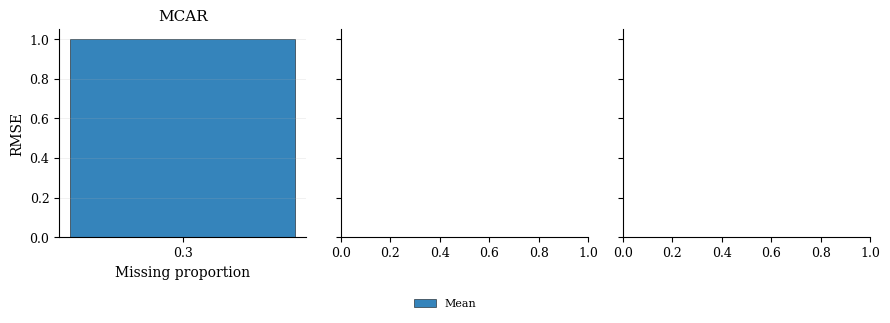

,Wasserstein,Mean shift,Var. retention,Corr. Frob.
Method,,,,
Mean,0.631,0.037,0.000,5.813


In [30]:
from common.visualization import plot_metric_bars, err_table, stat_fidelity_table

# ---------------------------------------------------------------------------
# Usage — pass either a DataFrame or a path to a CSV. Both work everywhere.
# ---------------------------------------------------------------------------

results_df.to_csv(CSV_DIR / "scenario5_imputation_results.csv", index=False)   
data_source = results_df

plot_metric_bars(data_source, "rmse", "RMSE", filename= FIGURES_DIR / "scenario5_rmse.png")

for mech in scenario_filter:
    display(err_table(data_source, mech)) 

display(stat_fidelity_table(data_source, scenario="MCAR", proportion=0.3))

# Downstream task evaluation

In [31]:
"""
Downstream beam-prediction evaluation for SQ3 (Scenario 5).

Pipeline per (mechanism, proportion, method, seed) cell:
  1. Split rows into train / test (a seeded random split is fine here).
  2. Ampute the training set's beam columns; test stays clean.
  3. Impute training beams.
  4. Labels: argmax over the 64 beams (clean for test, imputed-derived
     for train).
  5. Train the NN predictor on (GPS_train -> label_train).
  6. Evaluate Top-1 / Top-3 / Top-5 on clean test.
"""

import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------------------------
# Predictor: fully-connected NN (Morais & Alkhateeb, ICC 2023)
# ---------------------------------------------------------------------------

def predict_topk_mlp(gps_train, labels_train, gps_test,
                     n_classes=64, hidden=256, n_layers=3,
                     epochs=60, lr=1e-2, batch_size=32,
                     val_frac=0.25, seed=0, device=None):
    """Fully-connected NN matching Morais & Alkhateeb (ICC 2023), Table I.

    3 hidden layers x 256, ReLU, CE loss, Adam @ lr=1e-2 with multi-step
    decay (x0.2 at epochs 20, 40), 60 epochs, batch 32. Selects the epoch
    with best validation accuracy (val carved from the training rows).
    Returns ranked candidate labels (n_test, n_classes), labels in 1..64.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    torch.manual_seed(seed)
    np.random.seed(seed)

    y = labels_train.astype(int) - 1  # 1..64 -> 0..63

    # Internal train/val split (paper: 60/20/20 overall; here val out of train).
    n = len(gps_train)
    perm = np.random.default_rng(seed).permutation(n)
    n_val = max(1, int(round(val_frac * n)))
    val_i, tr_i = perm[:n_val], perm[n_val:]

    Xtr = torch.tensor(gps_train[tr_i], dtype=torch.float32, device=device)
    ytr = torch.tensor(y[tr_i],          dtype=torch.long,    device=device)
    Xva = torch.tensor(gps_train[val_i], dtype=torch.float32, device=device)
    yva = torch.tensor(y[val_i],          dtype=torch.long,    device=device)
    Xte = torch.tensor(gps_test,          dtype=torch.float32, device=device)

    layers, in_dim = [], gps_train.shape[1]
    for _ in range(n_layers):
        layers += [nn.Linear(in_dim, hidden), nn.ReLU()]
        in_dim = hidden
    layers += [nn.Linear(in_dim, n_classes)]
    model = nn.Sequential(*layers).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[20, 40], gamma=0.2)
    loss_fn = nn.CrossEntropyLoss()

    best_state, best_val_acc = None, -1.0
    idx = np.arange(len(tr_i))
    for epoch in range(epochs):
        model.train()
        np.random.shuffle(idx)
        for s in range(0, len(idx), batch_size):
            b = idx[s:s + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[b]), ytr[b])
            loss.backward()
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            val_acc = (model(Xva).argmax(1) == yva).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)  # best-val epoch, per the paper
    model.eval()
    with torch.no_grad():
        logits = model(Xte).cpu().numpy()

    ranked_idx = np.argsort(-logits, axis=1)
    return ranked_idx + 1  # back to 1..64


# ---------------------------------------------------------------------------
# Metric: Top-K accuracy from ranked candidates
# ---------------------------------------------------------------------------

def topk_accuracy(ranked_labels, true_labels, top_k=(1, 3, 5)):
    """ranked_labels: (n_test, n_classes), true_labels: (n_test,)."""
    out = {}
    for k in top_k:
        in_topk = np.any(ranked_labels[:, :k] == true_labels[:, None], axis=1)
        out[f"top{k}_acc"] = float(in_topk.mean())
    return out


# ---------------------------------------------------------------------------
# One downstream evaluation: (data_scaled, mask, imputer) -> metrics
# ---------------------------------------------------------------------------

def downstream_eval(data_scaled, beam_idx, gps_idx, mask, imputer, seed,
                    test_size=0.2):
    n_rows = data_scaled.shape[0]

    # Reproducible train/test split per seed.
    train_idx, test_idx = train_test_split(
        np.arange(n_rows), test_size=test_size, random_state=seed,
    )

    # --- Build the training matrix with masked beams; test stays clean. ---
    # The imputer is run ONLY on training rows. Otherwise test labels would
    # depend on imputation, defeating the point of held-out evaluation.
    data_train_masked = data_scaled[train_idx].copy()
    mask_train = mask[train_idx]
    data_train_masked[mask_train] = np.nan

    data_train_imputed = imputer.fit_transform(data_train_masked, seed=seed)

    # Defensive: fill any leftover NaNs with column means.
    if np.isnan(data_train_imputed).any():
        col_means = np.nanmean(data_train_masked, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_pos = np.isnan(data_train_imputed)
        data_train_imputed[nan_pos] = np.take(col_means, np.where(nan_pos)[1])

    # --- Derive labels: argmax across the 64 beam columns ---
    # Train labels come from imputed beams (the experimental variable).
    # Test labels come from clean beams (the ground truth).
    train_beams_imputed = data_train_imputed[:, beam_idx]
    test_beams_clean    = data_scaled[test_idx][:, beam_idx]

    labels_train = np.argmax(train_beams_imputed, axis=1) + 1   # 1..64
    labels_test  = np.argmax(test_beams_clean,    axis=1) + 1

    # --- Inputs: GPS, never imputed ---
    gps_train = data_scaled[train_idx][:, gps_idx]
    gps_test  = data_scaled[test_idx][:,  gps_idx]

    # --- Train + evaluate ---
    ranked = predict_topk_mlp(gps_train, labels_train, gps_test, seed=seed)
    return topk_accuracy(ranked, labels_test, top_k=(1, 3, 5))

In [32]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------------------------
# Bracketing baselines
# ---------------------------------------------------------------------------

def downstream_eval_clean(data_scaled, beam_idx, gps_idx, seed, test_size=0.2):
    """Upper bound: no amputation, train on clean labels.

    Same train/test split as the imputer runs (same seed) for comparability.
    """
    n_rows = data_scaled.shape[0]
    train_idx, test_idx = train_test_split(
        np.arange(n_rows), test_size=test_size, random_state=seed,
    )

    labels_train = np.argmax(data_scaled[train_idx][:, beam_idx], axis=1) + 1
    labels_test  = np.argmax(data_scaled[test_idx][:,  beam_idx], axis=1) + 1

    gps_train = data_scaled[train_idx][:, gps_idx]
    gps_test  = data_scaled[test_idx][:,  gps_idx]

    ranked = predict_topk_mlp(gps_train, labels_train, gps_test, seed=seed)
    return topk_accuracy(ranked, labels_test, top_k=(1, 3, 5))


def downstream_eval_drop(data_scaled, beam_idx, gps_idx, mask, seed, test_size=0.2):
    n_rows = data_scaled.shape[0]
    train_idx, test_idx = train_test_split(
        np.arange(n_rows), test_size=test_size, random_state=seed,
    )

    # Keep only training rows where NO beam is masked.
    keep = ~mask[train_idx][:, beam_idx].any(axis=1)
    train_idx_kept = train_idx[keep]

    # Edge case: at high missingness almost every row has a masked beam, so
    # this baseline can train on near-zero rows. That's a real finding worth
    # reporting (it shows why imputation is needed), not a bug.
    if len(train_idx_kept) < 10:
        return {f"top{k}_acc": float("nan") for k in (1, 3, 5)}

    labels_train = np.argmax(data_scaled[train_idx_kept][:, beam_idx], axis=1) + 1
    labels_test  = np.argmax(data_scaled[test_idx][:,        beam_idx], axis=1) + 1

    gps_train = data_scaled[train_idx_kept][:, gps_idx]
    gps_test  = data_scaled[test_idx][:,        gps_idx]

    ranked = predict_topk_mlp(gps_train, labels_train, gps_test, seed=seed)
    return topk_accuracy(ranked, labels_test, top_k=(1, 3, 5))


# ---------------------------------------------------------------------------
# Driver loop
# ---------------------------------------------------------------------------

def run_downstream_experiments(clean_data, imputers,
                               scenario_filter=None, verbose=True):
    from sklearn.preprocessing import StandardScaler

    validate_dataframe(clean_data)

    data_full   = clean_data[RETAINED_COLS].to_numpy(dtype=float)
    scaler      = StandardScaler()
    data_scaled = scaler.fit_transform(data_full)

    col_to_idx     = {c: i for i, c in enumerate(RETAINED_COLS)}
    beam_idx       = np.array([col_to_idx[c] for c in BEAM_COLS])
    mar_driver_idx = np.array([col_to_idx[c] for c in MAR_DRIVER_COLS])
    # GPS predictor inputs. unit2_direction is an addition to the Morais
    # baseline (lat/lon only) — drop it if you want to match the paper exactly.
    GPS_PREDICTOR_COLS = ["unit2_lat", "unit2_lon", "unit2_direction"]
    gps_idx = np.array([col_to_idx[c] for c in GPS_PREDICTOR_COLS])

    scenarios = [("MCAR", "mcar"), ("MAR", "mar"), ("MNAR", "mnar")]
    if scenario_filter is not None:
        scenarios = [s for s in scenarios if s[0] in scenario_filter]

    records = []
    t_start = time.time()

    # --- Clean baseline (one per seed; invariant across scenario/prop) ---
    for seed in range(N_SEEDS):
        res = downstream_eval_clean(data_scaled, beam_idx, gps_idx, seed)
        # Replicate across the grid so plotting is straightforward.
        for sc_name, _ in scenarios:
            for prop in PROPORTIONS:
                records.append({
                    "scenario": sc_name, "proportion": prop,
                    "method": "Clean", "seed": seed, **res,
                })

    # --- Per-cell imputer runs + drop-row baseline ---
    for scenario_name, mechanism in scenarios:
        for prop in PROPORTIONS:
            for seed in range(N_SEEDS):
                rng = np.random.default_rng(seed)
                if mechanism == "mcar":
                    mask = ampute_mcar(data_scaled.shape, prop, beam_idx, rng)
                elif mechanism == "mar":
                    mask = ampute_mar(data_scaled, prop, beam_idx, mar_driver_idx, rng)
                else:
                    mask = ampute_mnar(data_scaled, prop, beam_idx, rng)

                # Drop-rows baseline (no imputer needed)
                res = downstream_eval_drop(data_scaled, beam_idx, gps_idx, mask, seed)
                records.append({
                    "scenario": scenario_name, "proportion": prop,
                    "method": "DropMissing", "seed": seed, **res,
                })

                # Each imputer
                for imputer in imputers:
                    t0 = time.time()
                    res = downstream_eval(
                        data_scaled, beam_idx, gps_idx, mask, imputer, seed,
                    )
                    records.append({
                        "scenario": scenario_name, "proportion": prop,
                        "method": imputer.name, "seed": seed, **res,
                    })
                    if verbose:
                        print(f"  {scenario_name} p={prop} {imputer.name}: "
                              f"{time.time() - t0:.1f}s")

    if verbose:
        print(f"\nTotal runtime: {time.time() - t_start:.1f}s")

    return pd.DataFrame(records)

In [ ]:
imputers = [MeanImputer(), KNNImputerWrapper(), SoftImputeWrapper()]
downstream_df = run_downstream_experiments(clean_data, imputers=imputers, verbose=True)

downstream_df.to_csv(CSV_DIR / "scenario5_downstream_test.csv", index=False)

methods = ["Clean", "DropMissing", "Mean", "kNN", "MICE", "HyperImpute",
           "SoftImpute", "GRAPE", "DiffPuter"]

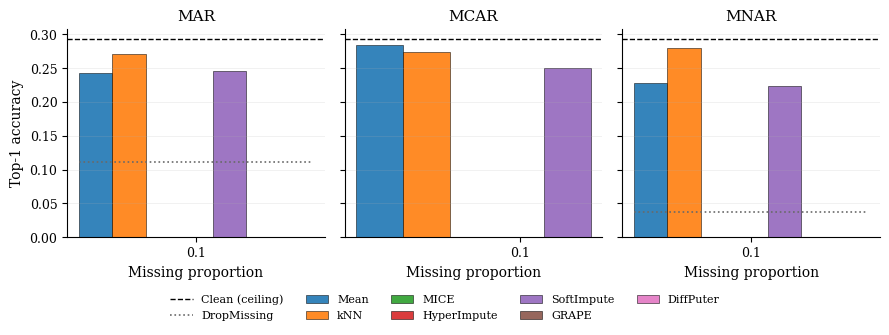

Clean baseline (Top-1): 0.29347826086956524
DropMissing baseline (Top-1):
scenario  proportion
MAR       0.1           0.110870
MCAR      0.1                NaN
MNAR      0.1           0.036957
Name: top1_acc, dtype: float64


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Imputer methods only — Clean and DropMissing are handled separately.
IMPUTER_METHODS = ["Mean", "kNN", "MICE", "HyperImpute",
                   "SoftImpute", "GRAPE", "DiffPuter"]


def plot_downstream_bars(data, metric, ylabel, filename=None):
    df = _as_dataframe(data)
    scenarios = sorted(df["scenario"].unique())
    proportions = sorted(df["proportion"].unique())

    # Aggregate everything once.
    agg = (df.groupby(["scenario", "proportion", "method"])[metric]
             .agg(["mean", "std"]).reset_index())

    fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharey=True)
    # Handle the case where only one scenario was run — plt.subplots returns
    # a single Axes, not an array, when n=1.
    if len(scenarios) == 1:
        axes = [axes] if not hasattr(axes, "__iter__") else axes

    cmap = plt.get_cmap("tab10")
    method_color = {m: cmap(i) for i, m in enumerate(IMPUTER_METHODS)}

    n_methods = len(IMPUTER_METHODS)
    n_props = len(proportions)
    bar_width = 0.8 / n_methods
    group_centers = np.arange(n_props)

    for ax_i, sc in enumerate(scenarios):
        ax = axes[ax_i] if len(scenarios) > 1 else axes[0]
        sub = agg[agg["scenario"] == sc]

        # --- Imputer bars ---
        for i, m in enumerate(IMPUTER_METHODS):
            d = (sub[sub["method"] == m]
                 .set_index("proportion")
                 .reindex(proportions))
            offsets = group_centers - 0.4 + (i + 0.5) * bar_width
            ax.bar(offsets, d["mean"], width=bar_width,
                   yerr=d["std"], label=m, color=method_color[m],
                   edgecolor="black", linewidth=0.4,
                   error_kw=dict(elinewidth=0.7, capsize=1.5, ecolor="black"),
                   alpha=0.9)

        # --- Clean baseline: single horizontal line spanning the panel ---
        # Clean doesn't vary with proportion; we take the mean across seeds.
        clean_rows = sub[sub["method"] == "Clean"]
        if not clean_rows.empty:
            clean_val = clean_rows["mean"].mean()
            ax.axhline(clean_val, color="black", linestyle="--", linewidth=1.0,
                       label="Clean (ceiling)" if ax_i == 0 else None,
                       zorder=10)

        # --- DropMissing baseline: one segment per proportion ---
        drop_rows = (sub[sub["method"] == "DropMissing"]
                     .set_index("proportion")
                     .reindex(proportions))
        if not drop_rows.empty:
            for j, p in enumerate(proportions):
                val = drop_rows.loc[p, "mean"]
                if not np.isnan(val):
                    ax.hlines(val,
                              xmin=group_centers[j] - 0.4,
                              xmax=group_centers[j] + 0.4,
                              colors="dimgray", linestyles=":", linewidth=1.2,
                              label="DropMissing" if (ax_i == 0 and j == 0) else None,
                              zorder=10)

        ax.set_title(sc)
        ax.set_xlabel("Missing proportion")
        ax.grid(axis="y", alpha=0.25, linewidth=0.5)
        ax.set_xticks(group_centers)
        ax.set_xticklabels([str(p) for p in proportions])

    axes[0].set_ylabel(ylabel)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center",
               ncol=min(len(labels), 5), bbox_to_anchor=(0.5, -0.12),
               frameon=False)
    fig.tight_layout()

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------------------------
# Usage — pass the FULL frame; the function pulls Clean/DropMissing internally.
# ---------------------------------------------------------------------------
plot_downstream_bars(downstream_df, "top1_acc", "Top-1 accuracy",
                     filename=FIGURES_DIR / "sq3_top1_test.png")

# Bracketing values, handy to quote in text:
print("Clean baseline (Top-1):",
      downstream_df[downstream_df["method"] == "Clean"]["top1_acc"].mean())
print("DropMissing baseline (Top-1):")
print(downstream_df[downstream_df["method"] == "DropMissing"]
      .groupby(["scenario", "proportion"])["top1_acc"].mean())